Imports

In [ ]:
import numpy as np
from scipy.stats import chi2
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 400

Globals

In [ ]:
n = 100
sigma2 = 1 / 3
beta0 = np.array([0.0, 0.0]) # H0 : beta = (0, 0)
alpha = 0.05
random_seed = np.random.default_rng(1342)

df = len(beta0) # deg de liberte

val_crit = chi2.ppf(1 - alpha, df)



Simulation

In [ ]:


x_raw = random_seed.uniform(0.0, 2.0, size = n)

y = np.where(x_raw < 1.0, x_raw - 0.5, 1.5 - x_raw)

X = np.column_stack((np.ones(n), x_raw))

XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
beta_hat = XtX_inv @ X.T @ y

res = y - X @ beta_hat
sigma2_hat = (res @ res) / (n - 2)


print("beta_hat      = ", beta_hat)


beta_hat      =  [ 0.0298269  -0.07458688]


Test de Wald

In [ ]:
diff = beta_hat - beta0
W = 1 / sigma2_hat * (diff @ XtX @ diff)
pW = 1 - chi2.cdf(W, df)

print("Test de Wald  = ", W)
print("Valeur p Wald = ", pW)


if W > val_crit:
    print("Conclusion    : Rejeter H0 (Significant)")
else:
    print("Conclusion    : Ne pas rejeter H0")

Test de Wald  =  5.135750724206737
Valeur p Wald =  0.07669832861058745
Conclusion    : Ne pas rejeter H0


Test de Rao

In [ ]:
diff = y - (X @ beta0)
R = 1 / sigma2_hat * (diff @ X @ XtX_inv @ X.T @ diff)
pR = 1 - chi2.cdf(R, df)

print("Test de Rao   = ", R)
print("Valeur p Rao  = ", pR)

if R > val_crit:
    print("Conclusion    : Rejeter H0 (Significant)")
else:
    print("Conclusion    : Ne pas rejeter H0")



Test de Rao   =  5.135750724206741
Valeur p Rao  =  0.07669832861058723
Conclusion    : Ne pas rejeter H0



Analyse et comparaisons



3.552713678800501e-15


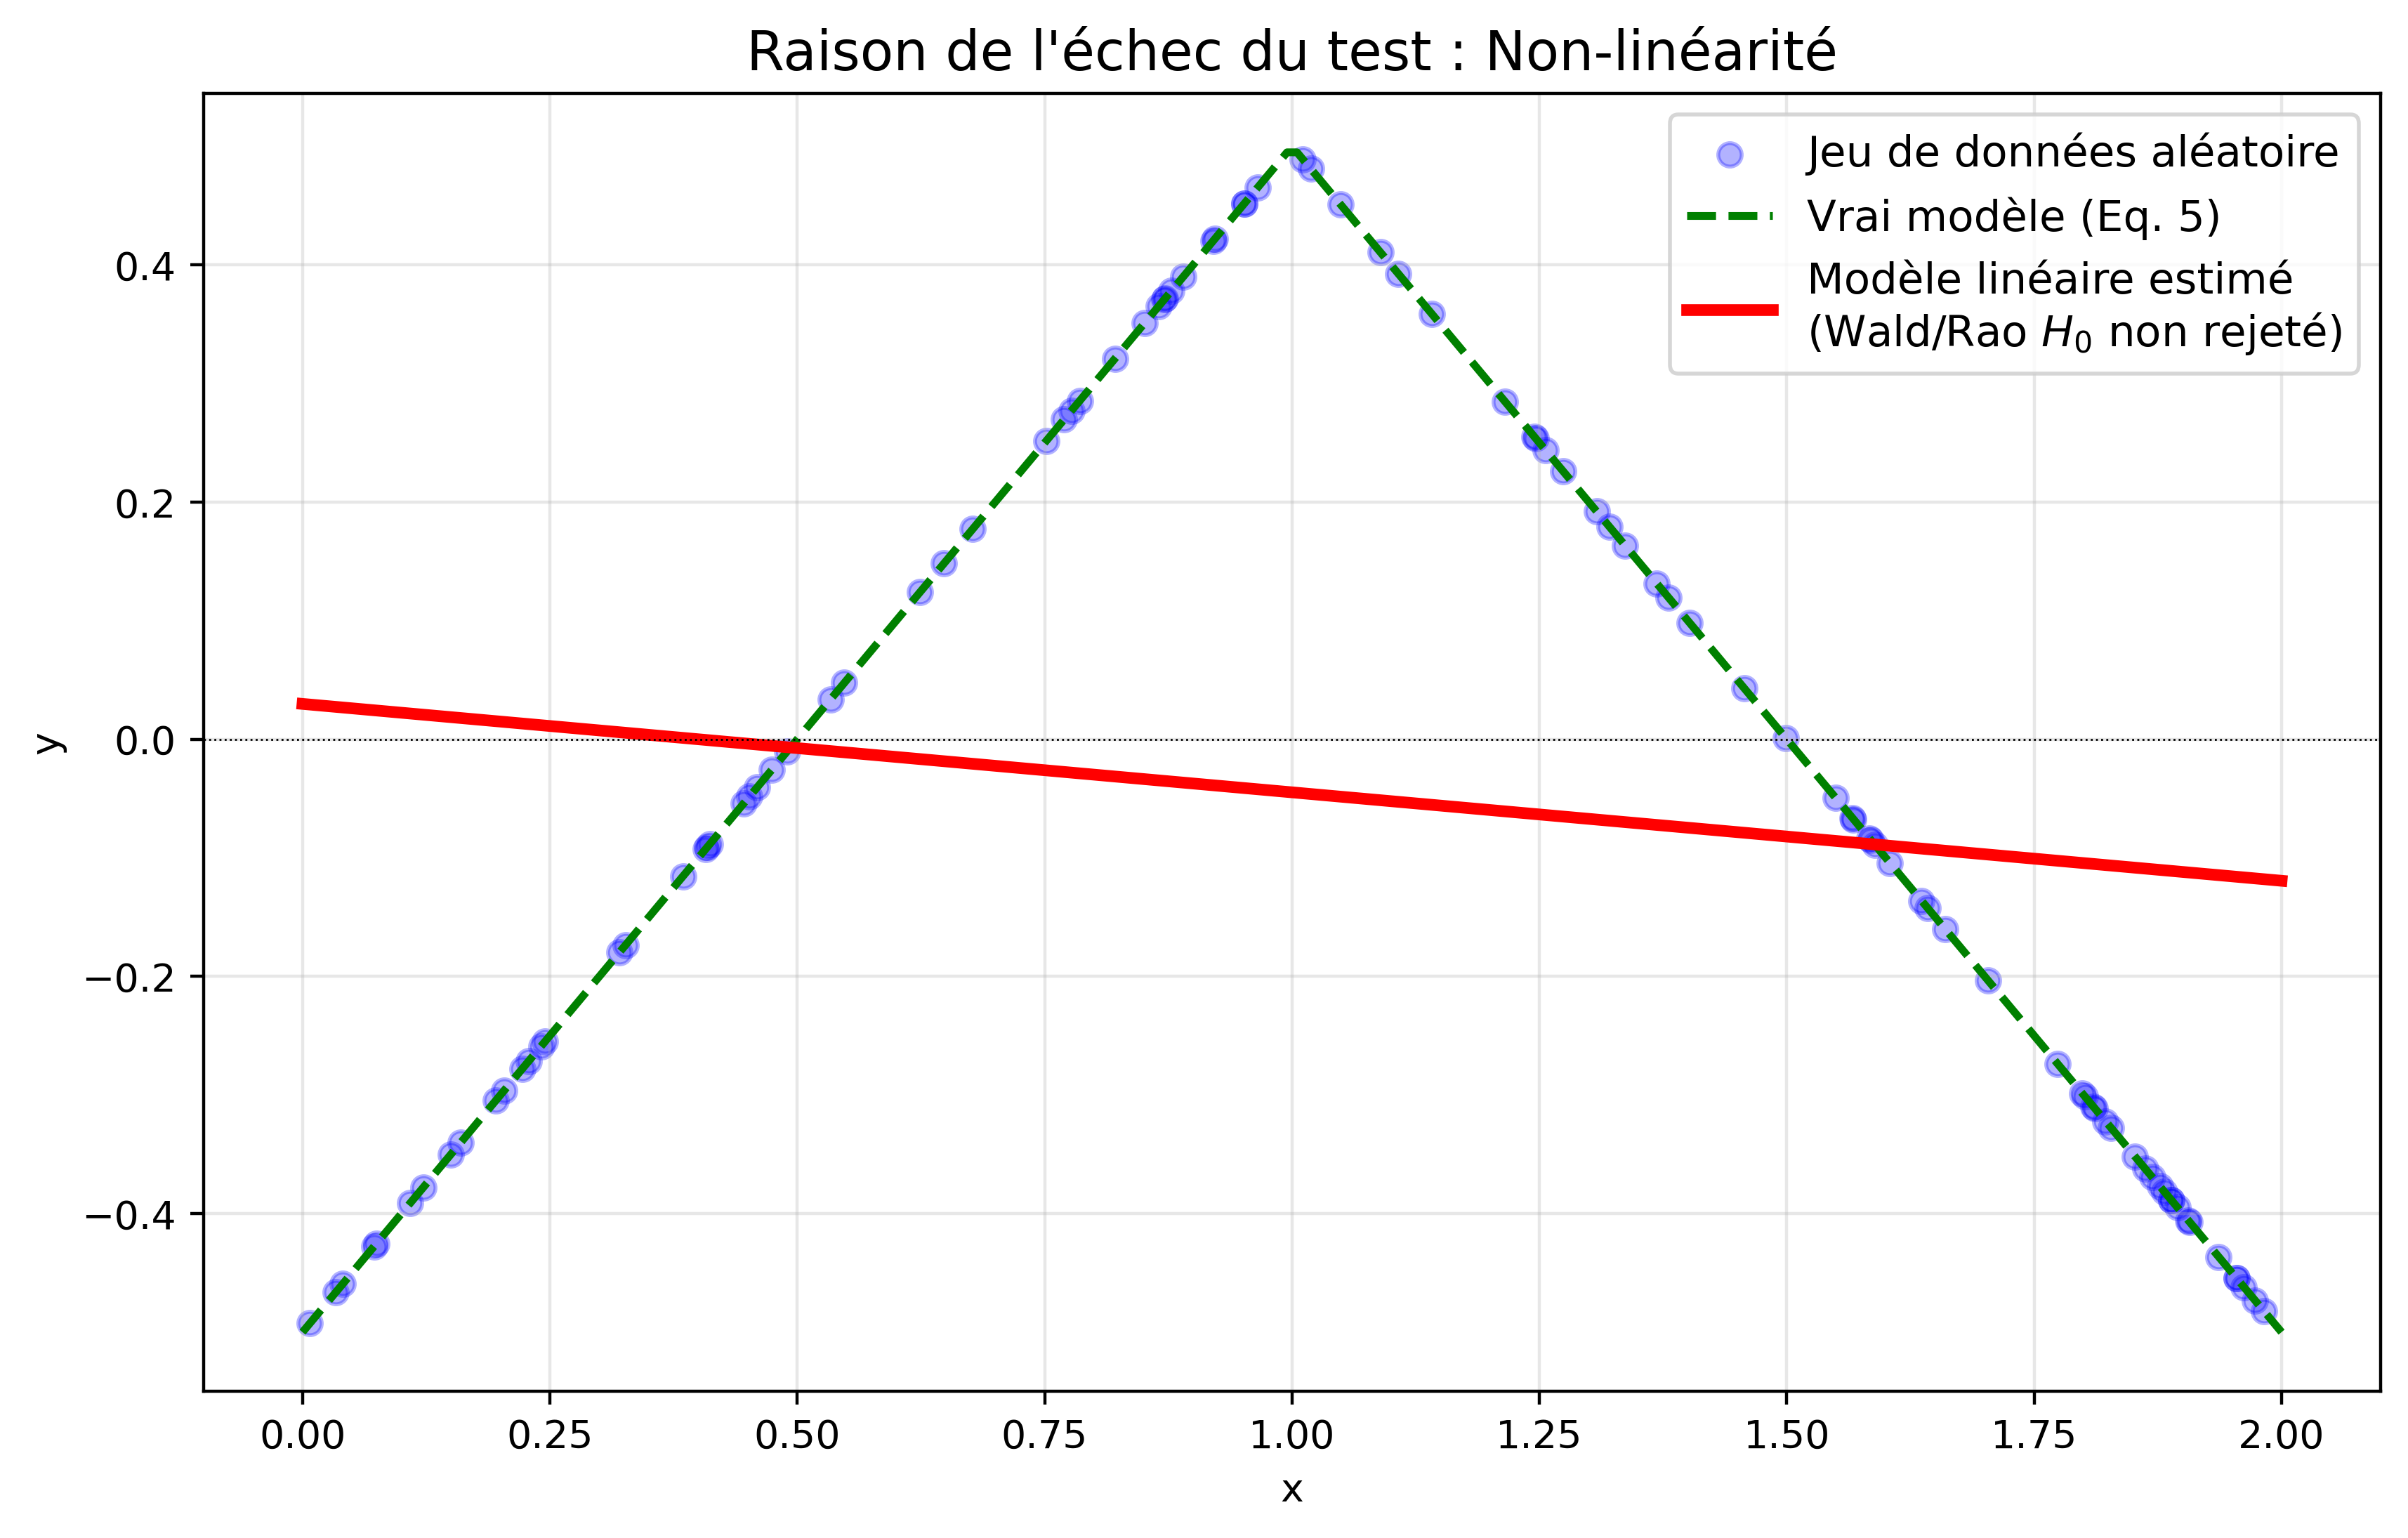

In [ ]:
print(abs(W - R))


x_grid = np.linspace(0, 2, 200)
y_true = np.where(x_grid < 1.0, x_grid - 0.5, 1.5 - x_grid)
y_est = beta_hat[0] + beta_hat[1] * x_grid
x_grid = np.linspace(0, 2, 200)
plt.figure(figsize=(10, 6))
plt.scatter(x_raw, y, color='blue', alpha=0.3, label='Jeu de données aléatoire')
plt.plot(x_grid, y_true, color='green', linestyle='--', linewidth=2, label='Vrai modèle (Eq. 5)')
plt.plot(x_grid, y_est, color='red', linewidth=3, label=f'Modèle linéaire estimé\n(Wald/Rao $H_0$ non rejeté)')
plt.title("Raison de l'échec du test : Non-linéarité", fontsize=14)
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, color='black', linewidth=0.5, linestyle=':')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.show()



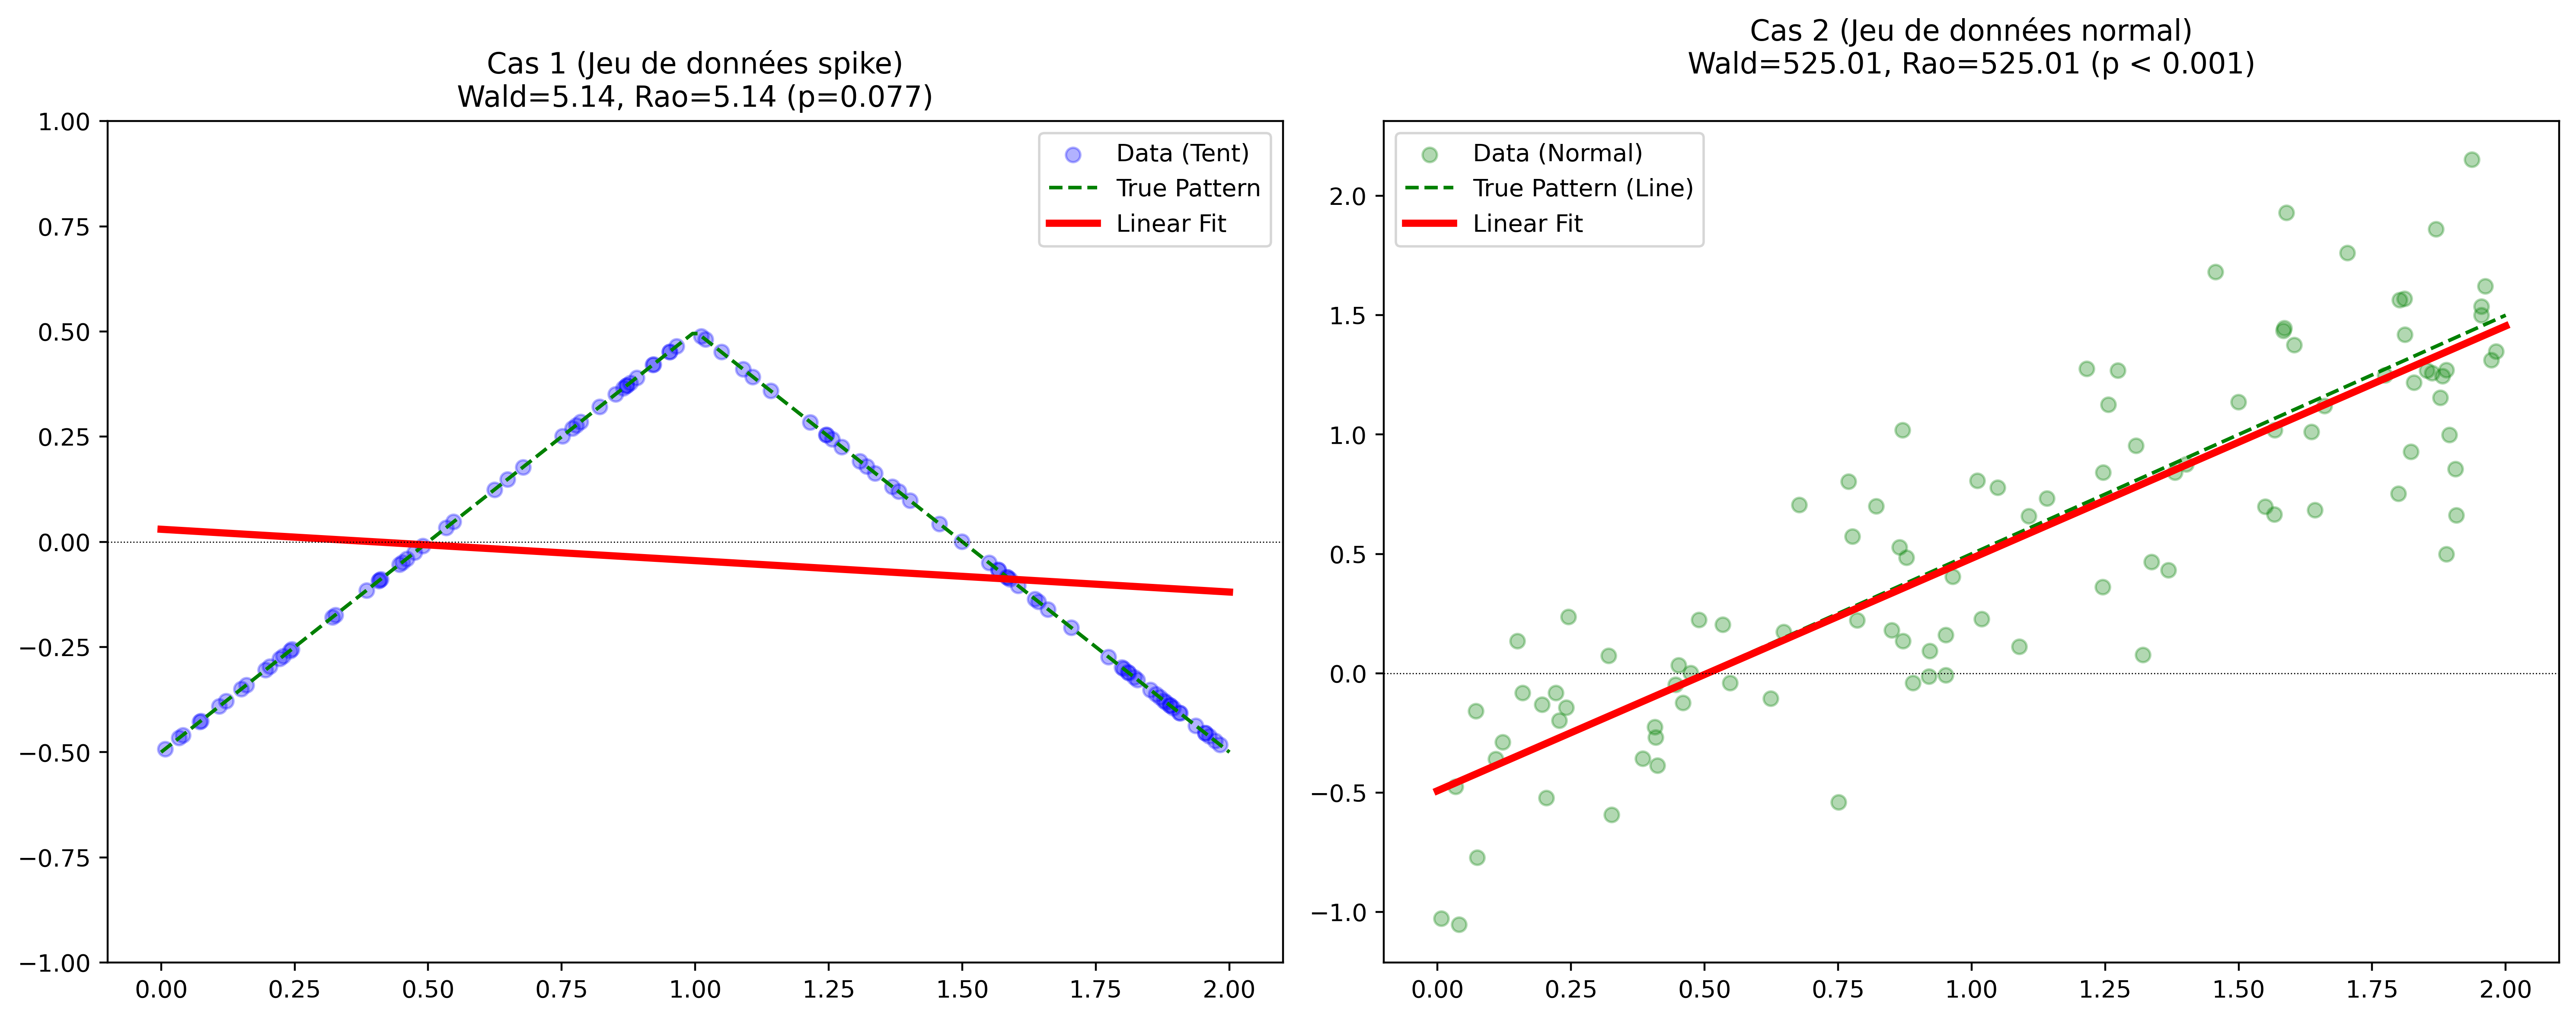

--- Cas 1: Spike ---
Wald : 5.13575, valeur p: 0.07670
Rao  : 5.13575, valeur p: 0.07670
|W - R|= 3.55e-15


--- Cas 2: Normal ---
Wald : 525.01397, valeur p: 0.00000e+00
Rao  : 525.01397, valeur p: 0.00000e+00
|W - R|= 6.82e-13


In [ ]:
def run_tests(y, X, beta0):
    n = len(y)

    # estimation MCO
    XtX = X.T @ X
    XtX_inv = np.linalg.inv(XtX)
    beta_hat = XtX_inv @ X.T @ y

    # Residu, variance
    res = y - X @ beta_hat
    sigma2_hat = (res @ res) / (n - 2)

    # W = (beta_hat - beta0)' * (XtX / sigma2) * (beta_hat - beta0)
    diff_w = beta_hat - beta0
    W = (diff_w.T @ XtX @ diff_w) / sigma2_hat
    p_W = 1 - chi2.cdf(W, df)

    # R = U(beta0)' * I(beta0)^-1 * U(beta0)
    diff_r = y - (X @ beta0)
    R = (diff_r.T @ X @ XtX_inv @ X.T @ diff_r) / sigma2_hat
    p_R = 1 - chi2.cdf(R, df)
    return beta_hat, W, p_W, R, p_R

# Random qui suit la densité à Q4
y_bad = np.where(x_raw < 1.0, x_raw - 0.5, 1.5 - x_raw)
beta_bad, W_bad, pW_bad, R_bad, pR_bad = run_tests(y_bad, X, beta0)

# Random qui suit la distribution normale
true_beta_norm = [-0.5, 1.0]
noise = random_seed.normal(0, np.sqrt(0.1), n)
y_norm = true_beta_norm[0] + true_beta_norm[1] * x_raw + noise
beta_norm, W_norm, pW_norm, R_norm, pR_norm = run_tests(y_norm, X, beta0)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x_grid = np.linspace(0, 2, 200)

axes[0].scatter(x_raw, y_bad, color='blue', alpha=0.3, label='Data (Tent)')
axes[0].plot(x_grid, np.where(x_grid<1, x_grid-0.5, 1.5-x_grid), 'g--', label='True Pattern')
axes[0].plot(x_grid, beta_bad[0] + beta_bad[1]*x_grid, 'r-', linewidth=3, label='Linear Fit')
axes[0].set_title(f"Cas 1 (Jeu de données spike)\nWald={W_bad:.2f}, Rao={R_bad:.2f} (p={pW_bad:.3f})", fontsize=12)
axes[0].axhline(0, color='black', linestyle=':', linewidth=0.5)
axes[0].legend()
axes[0].set_ylim(-1, 1)

axes[1].scatter(x_raw, y_norm, color='green', alpha=0.3, label='Data (Normal)')
axes[1].plot(x_grid, true_beta_norm[0] + true_beta_norm[1]*x_grid, 'g--', label='True Pattern (Line)')
axes[1].plot(x_grid, beta_norm[0] + beta_norm[1]*x_grid, 'r-', linewidth=3, label='Linear Fit')
axes[1].set_title(f"Cas 2 (Jeu de données normal)\nWald={W_norm:.2f}, Rao={R_norm:.2f} (p < 0.001)\n", fontsize=12)
axes[1].axhline(0, color='black', linestyle=':', linewidth=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"--- Cas 1: Spike ---")
print(f"Wald : {W_bad:.5f}, valeur p: {pW_bad:.5f}")
print(f"Rao  : {R_bad:.5f}, valeur p: {pR_bad:.5f}")
print(f"|W - R|= {abs(W_bad - R_bad):.2e}")
print("\n")
print(f"--- Cas 2: Normal ---")
print(f"Wald : {W_norm:.5f}, valeur p: {pW_norm:.5e}")
print(f"Rao  : {R_norm:.5f}, valeur p: {pR_norm:.5e}")
print(f"|W - R|= {abs(W_norm - R_norm):.2e}")